#  Лабораторная работа №2 «ДВПФ и ДПФ»
Курс: «Радиофизическая лаборатория» ФРКТ МФТИ


In [1]:
import numpy as np # импорт бибилиотеки numpy
import matplotlib.pyplot as plt # импорт модуля matplotlib.pyplot
from scipy import signal
from scipy.linalg import dft

In [2]:
# Для использования backend matplotlib inline/widget/notebook, раскомментируйте соответствующую строку ниже.
# Backend notebook используется в старых версиях. 
# Установка widget: pip install --upgrade jupyterlab ipympl
# %matplotlib inline
# %matplotlib notebook
%matplotlib widget

# Занятие 1. Основные свойства ДВПФ
Далее значения $N$, $L$, ${{\nu }_{0}}$ следует использовать из таблицы в соответствии с Вашим вариантом задания.

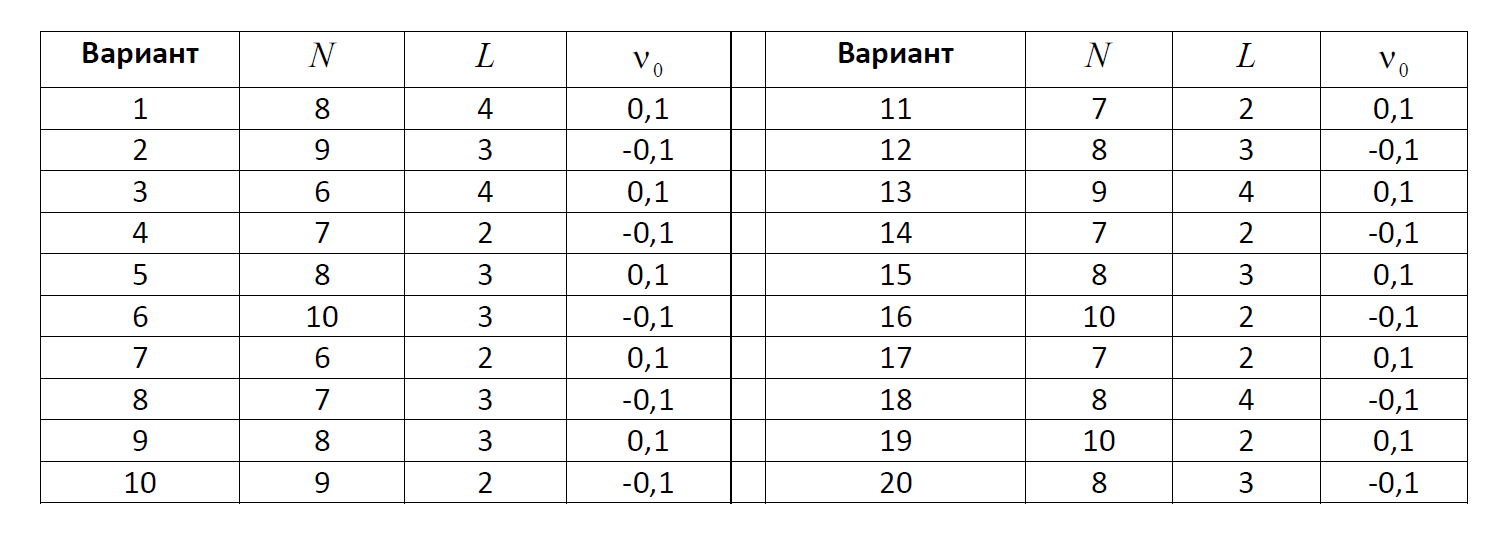

## Задача 1.1.  Прямоугольный импульс в дискретной форме.  

С помощью моделирования  вычислите и постройте график для модуля и фазы ДВПФ  $X_N(\nu)$  последовательности из $N$ последовательных единичных импульсов ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ для $\nu \in [-0,5; \;0,5]$.  Сравните результат с аналитической записью для  $X_N(\nu)$ (задача 1.б из задания к допуску).  Заполнить таблицу, используя результаты моделирования и аналитические записи. Принять частоту дискретизации равной 1 Гц. 

| Значение <br> X(0)  | Ширина $\Delta\nu$ главного лепестка <br> на нулевом уровне |  Точки скачков фазы <br> на $\pi$  |  Энергия$^2$ $\times\Delta t$ <br> $${\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu} $$  |
|:-----------:|:---:|:---:|:---:|
|             |     |     |     |

$^2$ Для дискретного сигнала рассматривают энергию $\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $, приходящуюся на один период частоты, т.е. на полосу частот шириной ${{f}_{\text{д}}}$:

$\int_{-0,5{{f}_{\text{д}}}}^{0,5{{f}_{\text{д}}}}{|}X(f){{|}^{2}}df=\frac{1}{\Delta t}\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu $
Для ее вычисления можно воспользоваться равенством Парсеваля для ДВПФ. 

Энергия равна $N = 8$

In [3]:
# Вариант 12
N = 8
L = 3
nu_0 = -0.1

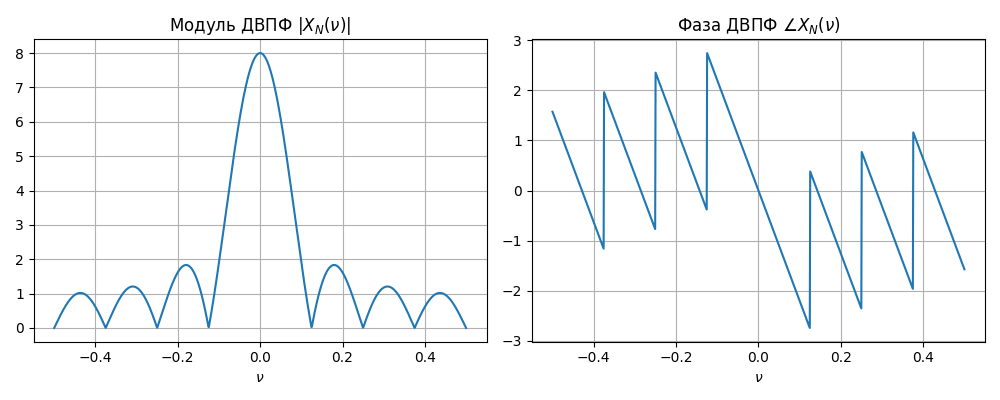

In [4]:
# Создаем последовательность x_N
k = np.arange(N)
x_N = np.ones(N)

# Вычисляем ДВПФ
nu = np.linspace(-0.5, 0.5, 1000)
X_N = np.array([np.sum(x_N * np.exp(-1j * 2 * np.pi * f * k)) for f in nu])

# Строим графики
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(nu, np.abs(X_N))
plt.title('Модуль ДВПФ $|X_N(\\nu)|$')
plt.xlabel('$\\nu$')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(nu, np.angle(X_N))
plt.title('Фаза ДВПФ $\\angle X_N(\\nu)$')
plt.xlabel('$\\nu$')
plt.grid(True)
plt.tight_layout()
plt.show()

## Задача 1.2.  Свойство масштабирования. 

Постройте последовательность ${{x}_{L}}[k]=\sum\limits_{m=-\infty }^{\infty }{{{x}_{N}}}[m]\mathbf{1}[k-mL]$, добавив $L-1$ нулевой отсчет между каждой парой соседних отсчетов сигнала ${{x}_{N}}[k]$ (из задачи 1.1). С помощью моделирования постройте модуль ее ДВПФ для $\nu \in [-0,5; \;0,5]$ и сравните результат с ${{X}_{N}}(\nu L)$ (из задачи 1.1).


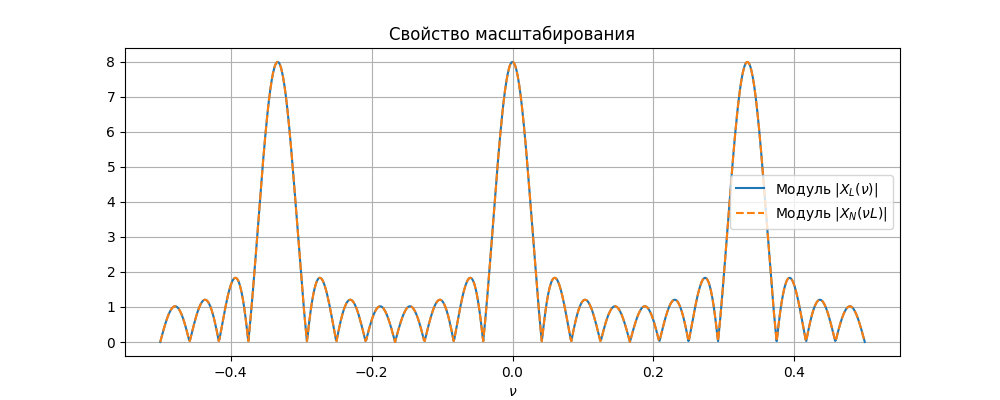

In [5]:
# Создаем x_L с добавлением нулей
x_L = np.zeros(N * L)
x_L[::L] = x_N  # каждый L-ый отсчет равен 1, остальные 0

k_L = np.arange(len(x_L))
X_L = np.array([np.sum(x_L * np.exp(-1j * 2 * np.pi * f * k_L)) for f in nu])

plt.figure(figsize=(10, 4))
plt.plot(nu, np.abs(X_L), label='Модуль $|X_L(\\nu)|$')
# Для сравнения строим X_N(nu * L)
X_N_scaled = np.array([np.sum(x_N * np.exp(-1j * 2 * np.pi * (f * L) * k)) for f in nu])
plt.plot(nu, np.abs(X_N_scaled), '--', label='Модуль $|X_N(\\nu L)|$')
plt.title('Свойство масштабирования')
plt.xlabel('$\\nu$')
plt.legend()
plt.grid(True)
plt.show()

## Задача 1.3.  Дифференцирование спектральной плотности.
Рассмотрите последовательность ${{x}_{D}}[k]=k\,{{x}_{N}}[k]$.  Постройте с помощью моделирования график для модуля ДВПФ этой последовательности ${{X}_{D}}(\nu )$ для $\nu \in [-0,5; \;0,5]$. 

** Получить численным или символьным дифференцированием график для $\frac{j}{2\pi }\frac{d{{X}_{N}}(\nu )}{d\nu }$ и сравнить его с ${{X}_{D}}(\nu ).$ 


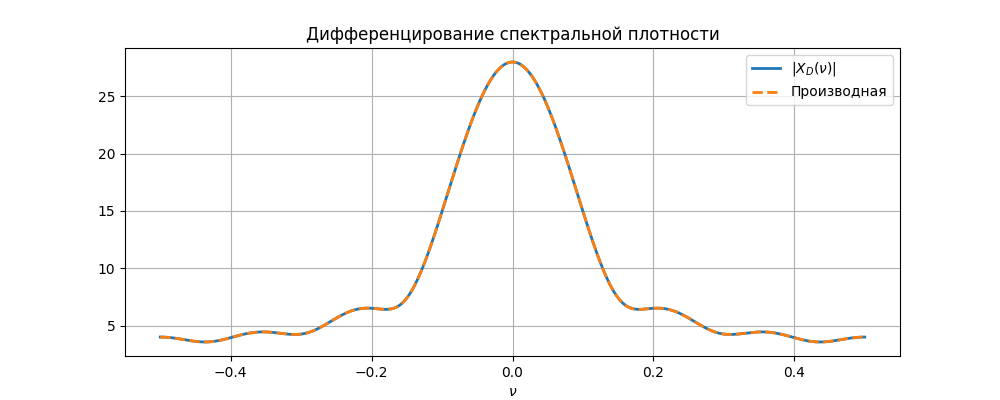

In [6]:
x_D = k * x_N
X_D = np.array([np.sum(x_D * np.exp(-1j * 2 * np.pi * f * k)) for f in nu])

# Численное дифференцирование X_N(nu)
dX_N_dnu = np.gradient(X_N, nu)
analytical_XD = (1j / (2 * np.pi)) * dX_N_dnu

plt.figure(figsize=(10, 4))
plt.plot(nu, np.abs(X_D), label='$|X_D(\\nu)|$', lw=2)
plt.plot(nu, np.abs(analytical_XD), '--', label='Производная', lw=2)
plt.title('Дифференцирование спектральной плотности')
plt.xlabel('$\\nu$')
plt.legend()
plt.grid(True)
plt.show()

## Задача 1.4. Теорема смещения.
С помощью моделирования получите график модуля спектральной плотности ${{X}_{S}}(\nu )$ для сигнала ${{x}_{S}}[k]={{x}_{N}}[k]\exp (j2\pi {{\nu }_{0}}k)$. Приведите ответы на следующие вопросы.

а) Какую аналитическую форму записи имеет функция ${{X}_{S}}(\nu )$?

б) Как результат моделирования соотносится с теоремой смещения для ДВПФ? 

в) Почему получившийся спектр не симметричен относительно нулевой частоты? 


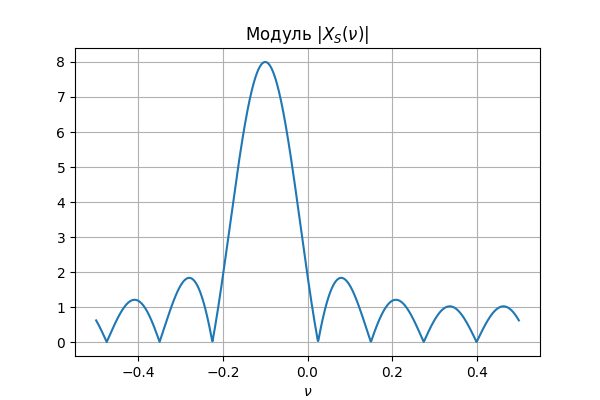

In [7]:
x_S = x_N * np.exp(1j * 2 * np.pi * nu_0 * k)
X_S = np.array([np.sum(x_S * np.exp(-1j * 2 * np.pi * f * k)) for f in nu])

plt.figure(figsize=(6, 4))
plt.plot(nu, np.abs(X_S))
plt.title('Модуль $|X_S(\\nu)|$')
plt.xlabel('$\\nu$')
plt.grid(True)
plt.show()

а) Аналитическая форма: $X_S(\nu) = \frac{sin(\pi(\nu - \nu_0)N)}{sin(\pi(\nu - \nu_0))} e^{-j\pi(\nu-\nu_0)(N-1)}$

б) Моделирование полностью подтверждает теорему смещения: спектр сместился вправо по оси частот ровно на $\nu_0$ (так как $\nu_0$ отрицательное, то смещение влево).

в) Спектр перестал быть симметричным относительно нуля, потому что сигнал $x_S[k]$ теперь является комплексным (вещественные сигналы всегда имеют симметричный модуль спектра, комплексные — нет).

## Задача 1.5. Теорема о свертке во временной области. 

Вычислите с помощью моделирования линейную дискретную свертку последовательности ${{x}_{N}}[k]=\sum\limits_{m=0}^{N-1}{\mathbf{1}}\left[ k-m \right]$ с точно такой же последовательностью. Постройте график для модуля ДВПФ  этой последовательности. Воспользовавшись теоремой о свертке, получите аналитическую запись ДВПФ. Заполните таблицу.

| Значение <br> X(0)  | Ширина $\Delta\nu$ главного лепестка <br> на нулевом уровне |  Энергия $\times\Delta t$ <br> $${\int_{-1/2}^{1/2}{|}X(\nu ){{|}^{2}}d\nu} $$  |
|:-----------:|:---:|:--------:|
|             |     |     |

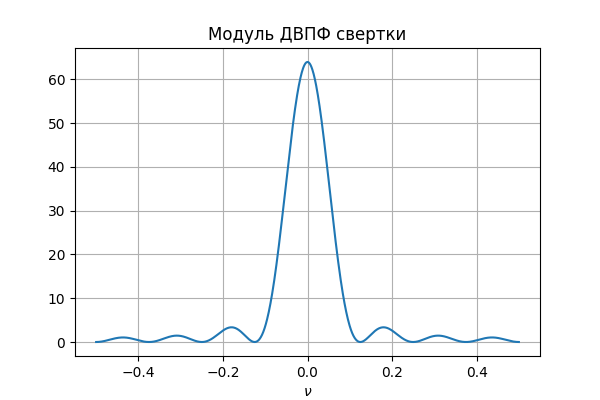

In [9]:
x_conv = np.convolve(x_N, x_N)
k_conv = np.arange(len(x_conv))

X_conv = np.array([np.sum(x_conv * np.exp(-1j * 2 * np.pi * f * k_conv)) for f in nu])

plt.figure(figsize=(6, 4))
plt.plot(nu, np.abs(X_conv))
plt.title('Модуль ДВПФ свертки')
plt.xlabel('$\\nu$')
plt.grid(True)
plt.show()

### Таблица 1.5. Параметры спектра свёртки двух прямоугольных импульсов

| Параметр | Аналитическое выражение / Значение |
| :--- | :--- |
| **Значение $X_{conv}(0)$** | $N^2$ |
| **Ширина главного лепестка $\Delta\nu$** | $\frac{2}{N}$ |
| **Энергия сигнала $E$** | $\frac{N(2N^2 + 1)}{3}$ |

По теореме Парсеваля $E = \sum |x_{conv}[k]|^2$. Для треугольного импульса, являющегося результатом автосвёртки прямоугольника амплитудой $1$ и длины $N$, сумма квадратов отсчетов вычисляется как:
    $$E = \sum_{i=1}^{N} i^2 + \sum_{j=1}^{N-1} j^2 = \frac{N(N+1)(2N+1)}{6} + \frac{(N-1)N(2N-1)}{6} = \frac{N(2N^2+1)}{3}$$

### Аналитическая запись ДВПФ свёртки

Пусть $x_{conv}[k] = x_N[k] * x_N[k]$, где $x_N[k]$ — прямоугольный импульс длины $N$.
ДВПФ исходного прямоугольного импульса:
$$X_N(\nu) = \frac{\sin(\pi \nu N)}{\sin(\pi \nu)} e^{-j \pi \nu (N-1)}$$

По теореме о свёртке:
$$X_{conv}(\nu) = X_N(\nu) \cdot X_N(\nu) = \left( X_N(\nu) \right)^2$$

Подставляя выражение для $X_N(\nu)$, получаем:
$$X_{conv}(\nu) = \left( \frac{\sin(\pi \nu N)}{\sin(\pi \nu)} \right)^2 e^{-j 2\pi \nu (N-1)}$$

# Занятие 2. Основные свойства ДПФ

Для задач 2.1 и 2.2 последовательность $x[k]$ генерируется с помощью следующего кода. 

In [10]:
Nv = 12 # Nv - номер варианта
x = np.random.rand(Nv+32)-0.5
x

array([-0.42161182,  0.0782298 , -0.37839503, -0.44926729, -0.2755882 ,
        0.03367408, -0.05124285, -0.03161433,  0.05729329, -0.098966  ,
        0.30304813, -0.20392387,  0.22970341, -0.02720644,  0.40121714,
        0.03222177, -0.33883765,  0.48516174,  0.3795009 , -0.47341324,
       -0.28177669,  0.08841694, -0.31304539, -0.12102117, -0.08698543,
        0.13945179, -0.11120032,  0.15981403,  0.42963699,  0.38521301,
        0.07355569, -0.19043387,  0.27746718,  0.46796509, -0.13764898,
        0.17619623, -0.2267745 , -0.4783252 , -0.31414814, -0.48571945,
       -0.14704038, -0.47217472, -0.29095499,  0.4190955 ])

## Задача 2.1. Алгоритмы вычисления ДПФ. 

Вычислите ДПФ $X[n]$ для последовательности $x[k]$. Воспользуйтесь следующими способами:

а) вычисление с использованием матричной формы ДПФ;

б) алгоритм быстрого преобразование Фурье (БПФ).

Сравните результаты. 


In [12]:
N_dft = len(x)

# а) Матричная форма
W = dft(N_dft)
X_matrix = W @ x

# б) Алгоритм БПФ (FFT)
X_fft = np.fft.fft(x)

# Сравнение
difference = np.max(np.abs(X_matrix - X_fft))
print(f"Максимальная разность между матричным вычислением и БПФ: {difference}")

Максимальная разность между матричным вычислением и БПФ: 9.212423007634173e-14


## Задача 2.2  Свойства симметрии ДПФ. 

Для последовательности $x[k]$ постройте графики $\text{Re}\ X[n]$, $\text{Im}\ X[n]$, $\left| X[n] \right|$, $\angle \ X[n]$.

Сравните получившиеся результаты со свойствами симметрии ДПФ. 


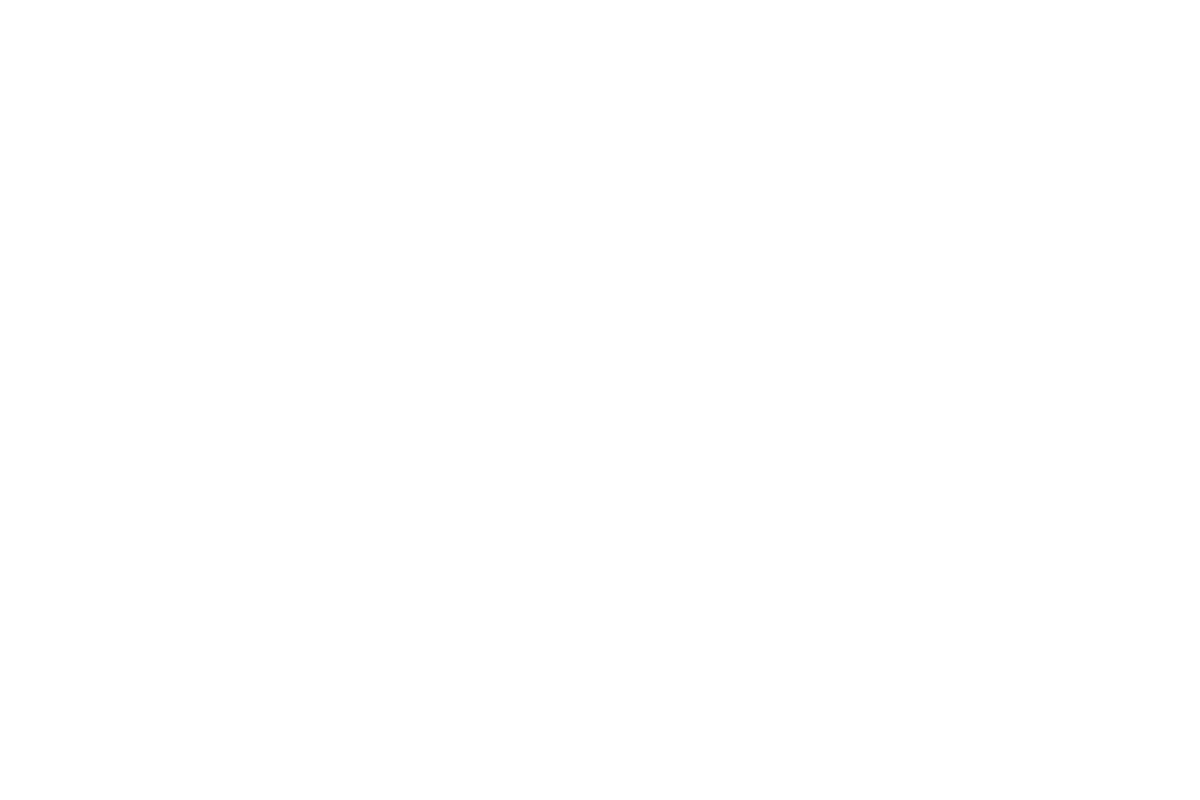

In [13]:
n_indices = np.arange(N_dft)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.stem(n_indices, np.real(X_fft))
plt.title('Re X[n] (Четная симметрия)')

plt.subplot(2, 2, 2)
plt.stem(n_indices, np.imag(X_fft))
plt.title('Im X[n] (Нечетная симметрия)')

plt.subplot(2, 2, 3)
plt.stem(n_indices, np.abs(X_fft))
plt.title('|X[n]| (Четная симметрия)')

plt.subplot(2, 2, 4)
plt.stem(n_indices, np.angle(X_fft))
plt.title('Фаза X[n] (Нечетная симметрия)')

plt.tight_layout()
plt.show()

Вывод: Графики подтверждают, что для вещественного сигнала модуль и действительная часть спектра ДПФ являются четными относительно центра N/2, а фаза и мнимая часть -- нечетными.

## Задача 2.3.  Циклический сдвиг в ДПФ. 


Постройте график для последовательности $q[k]=k+1$ при $0\le k < 8$, иначе  $q[k]=0$.

Вычислите последовательность $y[k]$, ДПФ которой 
$Y[n]=\exp \left( -j\frac{2\pi }{8}mn \right)Q[n]$.

Сравните получившиеся последовательности. 


Параметр $m$ для задачи 2.3 генерируется с помощью следующего кода. 

In [14]:
Nv = 12 # Nv - номер варианта
m = max(Nv % 8, 1)
print("m =", m)

m = 4


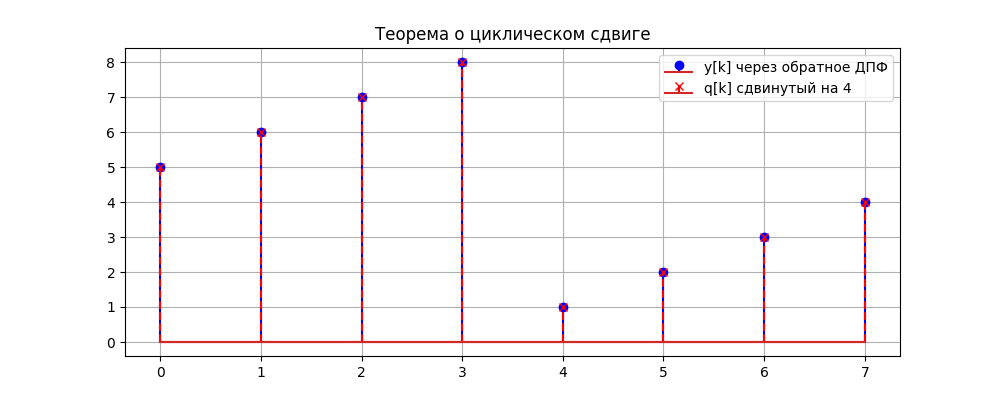

In [15]:
# Создаем q[k]
q = np.zeros(8)
q[:8] = np.arange(8) + 1

# ДПФ Q[n]
Q = np.fft.fft(q)

# Умножение на экспоненту (эквивалент циклического сдвига)
n_idx = np.arange(8)
Y = Q * np.exp(-1j * 2 * np.pi * m * n_idx / 8)

# Обратное ДПФ для нахождения y[k]
y = np.real(np.fft.ifft(Y))

# Циклический сдвиг во временной области напрямую
q_shifted = np.roll(q, m)

plt.figure(figsize=(10, 4))
plt.stem(np.arange(8), y, linefmt='b-', markerfmt='bo', label='y[k] через обратное ДПФ')
plt.stem(np.arange(8), q_shifted, linefmt='r--', markerfmt='rx', label=f'q[k] сдвинутый на {m}')
plt.title('Теорема о циклическом сдвиге')
plt.legend()
plt.grid(True)
plt.show()

# Занятие 3. Связь ДВПФ и ДПФ

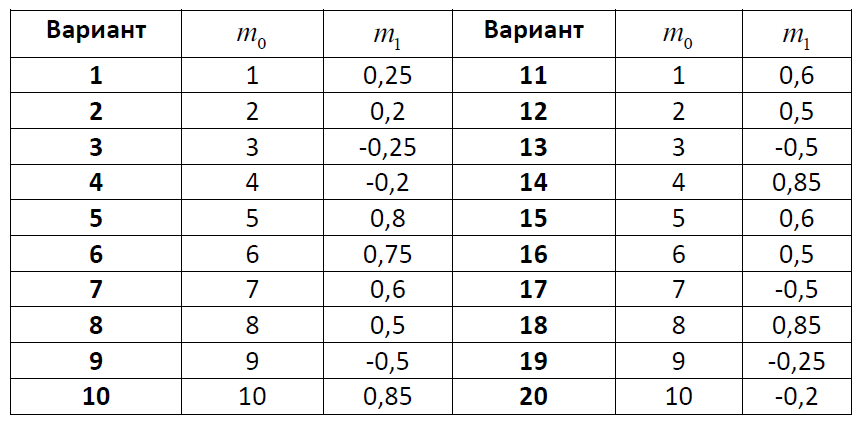

## Задача 3.1. Интерполяция  ДВПФ добавлением нулевых отсчетов в сигнал.

Постройте на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$ последовательности ($N=32$)
$$x[k]=\left\{ \begin{array}{*{35}{l}}
   \sin \left( \dfrac{2\pi }{N}{{m}_{0}}k \right)+\sin \left( \dfrac{2\pi }{N}\left( {{m}_{0}}+0,25 \right)k \right),\ 0\le k\le N-1;  \\
   0,\ \ \text{при других }k.  \\
\end{array} \right.$$
Увеличьте размерность ДПФ, добавив нулевые отсчеты так, чтобы все относительные частоты синусоид попадали на бины ДПФ.  Приведите на одном графике модули ДВПФ $\left| X(\nu ) \right|$ и ДПФ $\left| X[n] \right|$  для этого случая. Сравните результаты. 

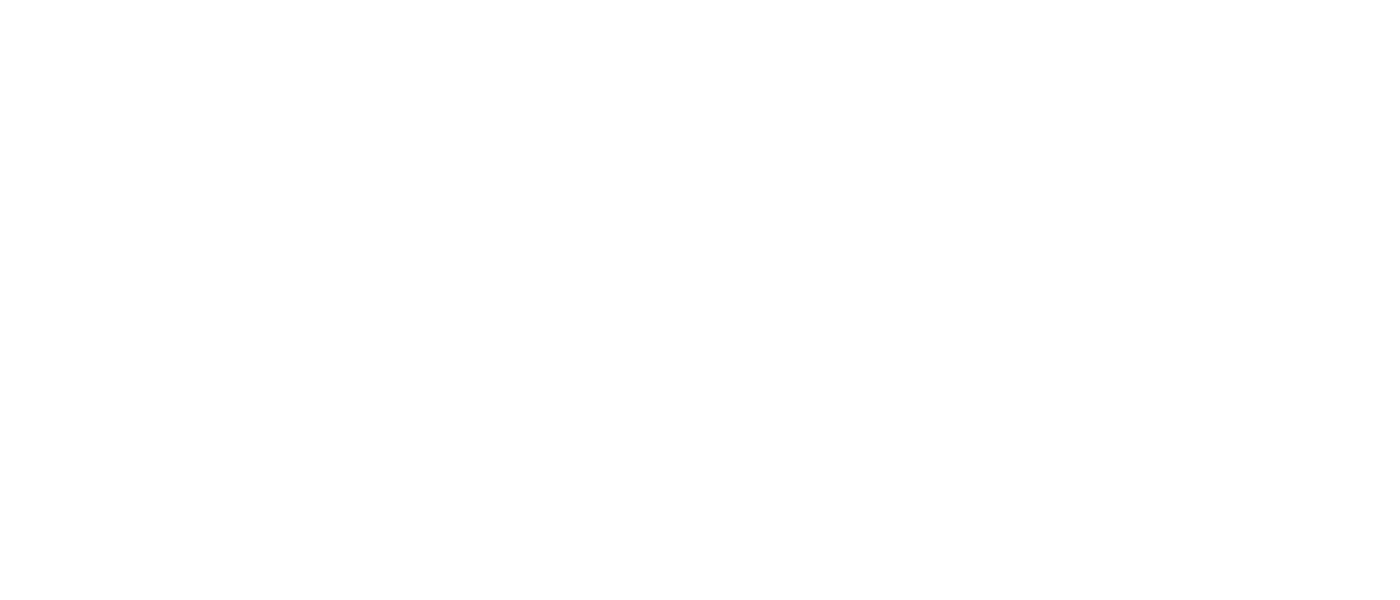

In [16]:
N = 32
m0 = 2
m1 = 0.5

k = np.arange(N)
x = np.sin(2 * np.pi / N * m0 * k) + np.sin(2 * np.pi / N * (m0 + 0.25) * k)

def calc_dtft(signal, M_dtft=2048):
    X = np.fft.fftshift(np.fft.fft(signal, M_dtft))
    nu = np.arange(M_dtft) / M_dtft - 0.5
    return nu, X

nu_dtft, X_dtft = calc_dtft(x)

X_dft_32 = np.fft.fftshift(np.fft.fft(x))
nu_dft_32 = np.arange(N) / N - 0.5

M = 128 # 32 * 4, чтобы учесть дробную часть 0.25
x_padded = np.pad(x, (0, M - N), 'constant')
X_dft_128 = np.fft.fftshift(np.fft.fft(x_padded))
nu_dft_128 = np.arange(M) / M - 0.5

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(nu_dtft, np.abs(X_dtft), 'C1', label='ДВПФ (огибающая)')
plt.stem(nu_dft_32, np.abs(X_dft_32), linefmt='C0-', markerfmt='C0o', basefmt='C0-', label=f'ДПФ (N={N})')
plt.xlim([-0.5, 0.5])
plt.title('Без добавления нулей (N=32)')
plt.xlabel('$\\nu$')
plt.ylabel('$|X(\\nu)|$, $|X[n]|$')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(nu_dtft, np.abs(X_dtft), 'C1', label='ДВПФ (огибающая)')
plt.stem(nu_dft_128, np.abs(X_dft_128), linefmt='C2-', markerfmt='C2o', basefmt='C2-', label=f'ДПФ (M={M})')
plt.xlim([-0.5, 0.5])
plt.title('С добавлением нулей (M=128)')
plt.xlabel('$\\nu$')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Задача 3.2. ДВПФ и ДПФ периодической последовательсти.

Простройте графики для действительной  и мнимой части коэффициентов ДПФ $\tilde{X}[n]$ периодической последовательности $x[k]=\cos \left( \frac{2\pi }{N}mk \right)+\sin \left( \frac{2\pi }{N}mk \right)$  с периодом $N=32$, для случаев $m={{m}_{0}}$ и $m={{m}_{0}}+{{m}_{1}}$. Получите аналитическую запись ДПФ. Сравните ДПФ последовательности с ее ДВПФ. Определите, выполняется ли связь между весами дельта-функций в ДВПФ и величинами отсчетов ДПФ. 

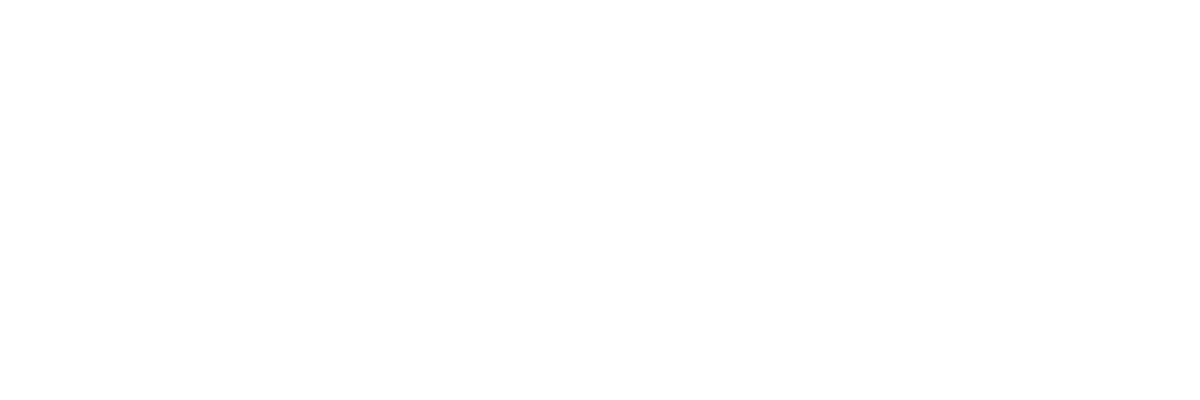

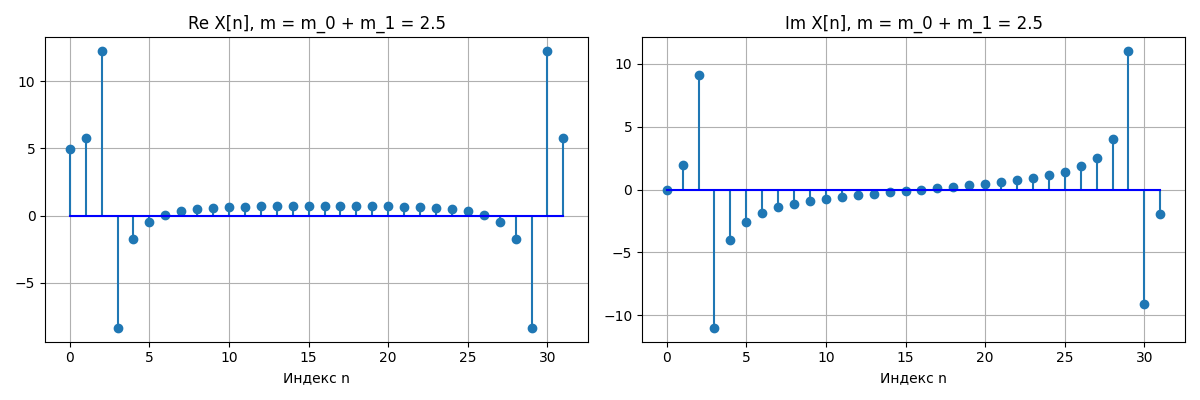

In [32]:
def plot_periodic_dft(m_val, title_suffix):
    k = np.arange(N)
    x_per = np.cos(2 * np.pi / N * m_val * k) + np.sin(2 * np.pi / N * m_val * k)

    X_per = np.fft.fft(x_per)
    n_idx = np.arange(N)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.stem(n_idx, np.real(X_per), basefmt='b-')
    plt.title(r"Re X[n], m = " + title_suffix)
    plt.xlabel('Индекс n')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.stem(n_idx, np.imag(X_per), basefmt='b-')
    plt.title(r"Im X[n], m = " + title_suffix)
    plt.xlabel('Индекс n')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_periodic_dft(m0, f'm_0 = {m0}')

plot_periodic_dft(m0 + m1, f'm_0 + m_1 = {m0 + m1}')

**Аналитическая запись ДПФ:**
По формуле Эйлера исходный сигнал можно расписать как:
$$x[k] = \cos\left(\frac{2\pi}{N}mk\right) + \sin\left(\frac{2\pi}{N}mk\right) = \frac{e^{j\frac{2\pi}{N}mk} + e^{-j\frac{2\pi}{N}mk}}{2} + \frac{e^{j\frac{2\pi}{N}mk} - e^{-j\frac{2\pi}{N}mk}}{2j}$$
Учитывая, что $1/j = -j$:
$$x[k] = \left(\frac{1}{2} - j\frac{1}{2}\right)e^{j\frac{2\pi}{N}mk} + \left(\frac{1}{2} + j\frac{1}{2}\right)e^{-j\frac{2\pi}{N}mk}$$
Из этого следует, что ДПФ $X[n]$ будет иметь ровно два ненулевых отсчета:
1. На частоте $n = m$: $X[m] = N\left(\frac{1}{2} - j\frac{1}{2}\right) = \frac{N}{2} - j\frac{N}{2}$
2. На частоте $n = N - m$: $X[N-m] = N\left(\frac{1}{2} + j\frac{1}{2}\right) = \frac{N}{2} + j\frac{N}{2}$

**Сравнение ДПФ и ДВПФ:** ДВПФ периодической последовательности представляет собой бесконечную сумму дельта-функций (спектр дискретный). ДПФ представляет собой один период этого дискретного спектра (конечное число гармоник).

**Связь между весами дельта-функций в ДВПФ и отсчетами ДПФ:**
Выполняется жесткая связь. Веса дельта-функций в ДВПФ периодического сигнала равны коэффициентам разложения сигнала в ряд Фурье (обычно обозначаются как $C_k$). В то же время отсчеты ДПФ $\tilde{X}[n]$ связаны с этими коэффициентами соотношением:
$\tilde{X}[n] = N \cdot C_n$

То есть, отсчет ДПФ в N раз больше веса соответствующей дельта-функции в ДВПФ. (В нашем случае аналитический вес дельта-функции на частоте $m/N$ равен $0.5−j0.5$, а отсчет ДПФ равен $16−j16$ при $N=32$, что ровно в 32 раза больше).

# Примеры вычислений на Python для лабораторной работы №2 "ДВПФ и ДПФ"

## Задание последовательности отсчетов

Зададим последовательность из 10 единичных импульсов $w[k] = \sum_{m=0}^{N-1} \mathbf{1}[k-m]$

In [5]:
w = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
w

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Сделаем тоже самое с помощью функции `ones`

In [6]:
w1=np.ones(10)
w1

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Выведем график последовательности $w[k] = \sum_{m=0}^{N-1} \mathbf{1}[k-m]$

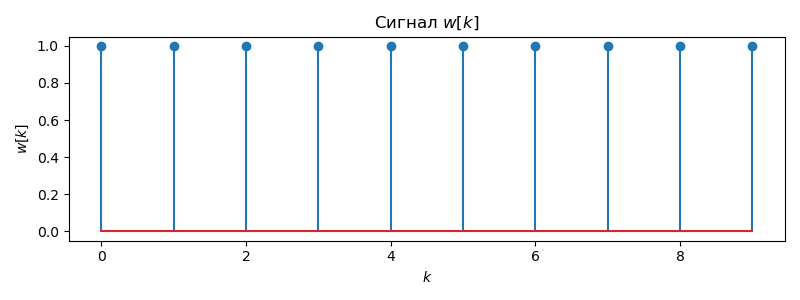

In [7]:
N=len(w)
k = np.arange(N)
plt.figure(figsize=[8, 3])
plt.stem(k, w)
plt.title('Сигнал $w[k]$')
plt.xlabel('$k$')
plt.ylabel('$w[k]$')
plt.tight_layout()
plt.show()

Определим последовательность вида $y[k]=\exp(j2\pi \nu_0 k) w[k]$

In [8]:
k = np.arange(N)
nu_0 = 0.25
y=np.exp(1j*2*np.pi*nu_0*k)
y

array([ 1.0000000e+00+0.0000000e+00j,  6.1232340e-17+1.0000000e+00j,
       -1.0000000e+00+1.2246468e-16j, -1.8369702e-16-1.0000000e+00j,
        1.0000000e+00-2.4492936e-16j,  3.0616170e-16+1.0000000e+00j,
       -1.0000000e+00+3.6739404e-16j, -4.2862638e-16-1.0000000e+00j,
        1.0000000e+00-4.8985872e-16j,  5.5109106e-16+1.0000000e+00j])

Определим дискретную линейную свертку (Convolution) последовательности $w[k]$ c точно такой же последовательностью.

In [9]:
w2=signal.convolve(w, w)
w2

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  9,  8,  7,  6,  5,  4,  3,
        2,  1])

Выведем график для такой последовательности:

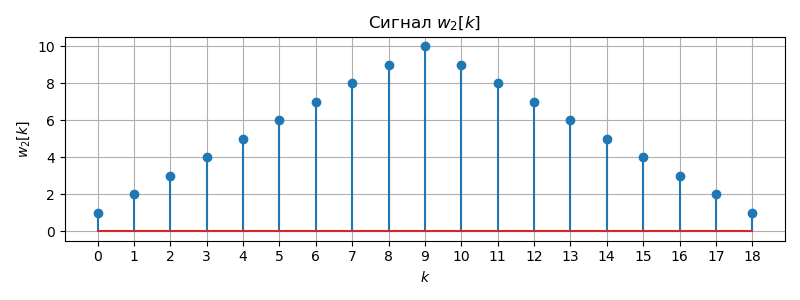

In [10]:
N=len(w2)
k = np.arange(0, N)
plt.figure(figsize=[8, 3])
plt.stem(k, w2)
plt.title('Сигнал $w_2[k]$')
plt.xlabel('$k$')
plt.ylabel('$w_2[k]$')
plt.grid()
plt.xticks(k) # установить деления шкалы абсцисс для каждого отсчета
plt.tight_layout()
plt.show()

Поэлементное умножение задается оператором `*`

In [11]:
w2*w2

array([  1,   4,   9,  16,  25,  36,  49,  64,  81, 100,  81,  64,  49,
        36,  25,  16,   9,   4,   1])

## Вычисление ДВПФ

Определим ДВПФ последовательности $w[k]=\sum_{m=0}^{N-1} \mathbf{1}[k-m]$ 

In [12]:
def dtft(x, M=2048):
    return  np.arange(M)/M-0.5, np.fft.fftshift(np.fft.fft(x, M))

In [13]:
nu, W = dtft(w, M=2048)

* `nu` — массив частот $\nu \in [-0.5;0.5)$ с шагом сетки $\Delta \nu =1/M$,
* `W` — значения ДВПФ $W(\nu )$ в этих точках, 
* `dtft` — функция, 
* `w` — последовательность отсчетов, 
* `M` — число точек на сетки оси частот, в которых вычисляется ДВПФ. 

Построим график для модуля ДВПФ

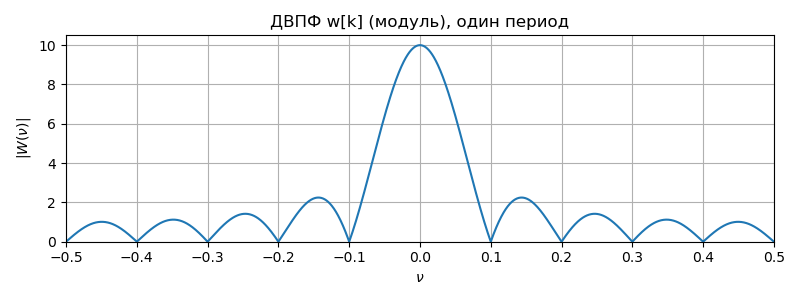

In [14]:
plt.figure(figsize=[8, 3])
nu, W = dtft(w, M=2048)
plt.plot(nu, abs(W))

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ w[k] (модуль), один период')
plt.xlabel('$\\nu$')
plt.ylabel('$|W(\\nu)|$')

plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

Теперь выведем фазовую часть ДВПФ

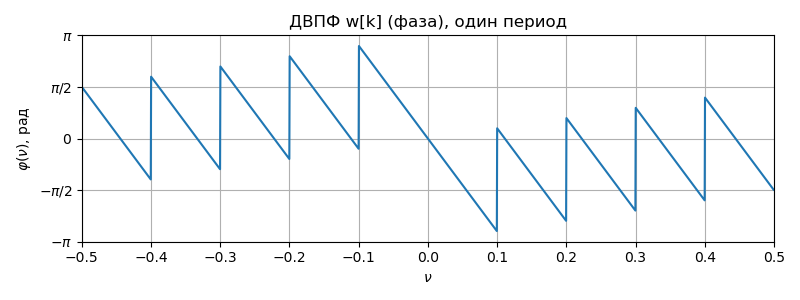

In [15]:
plt.figure(figsize=[8, 3])
plt.plot(nu, np.angle(W))
plt.xlim([-0.5, 0.5])
plt.ylim([-np.pi, np.pi])
plt.title('ДВПФ w[k] (фаза), один период')
plt.xlabel('$\\nu$')
plt.ylabel('$\\varphi(\\nu)$, рад')
plt.yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=("$-\\pi$", "$-\\pi/2$", "$0$", "$\\pi/2$", "$\\pi$"))
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

## Вычисление ДПФ

Вычислим ДПФ $N$-точечной последовательности

$$x[k]=\sin \left(2\pi \frac{2}{N}k\right)+\cos \left(2\pi \frac{3}{N}k\right),\;\;k=0,1,\dots ,N-1,\;\;N=8.$$

Формула прямого ДПФ в данном случае без нормирующего множителя $1/N$:
$$X[n]=\sum_{k=0}^{N-1} x[k]\exp \left(-j2\pi \frac{nk}{N}\right)$$
Сначала воспользуемся матричной формой ДПФ. Функция `scipy.linalg.dft(N)` возвращает матрицу ДПФ $[W]_N$ размера $N\times N$. 


In [16]:
N=8
k=np.arange(N)
x=np.sin(2*np.pi*2/N*k)+np.cos(2*np.pi*3/N*k)
W8 = dft(N)
Xn = W8 @ x
Xn

array([-8.07156228e-17+0.00000000e+00j,  8.88178420e-16-7.96639400e-16j,
        1.85570158e-16-4.00000000e+00j,  4.00000000e+00+1.30505585e-16j,
        1.25155201e-15+8.87468518e-31j,  4.00000000e+00+4.75447572e-15j,
       -5.11882929e-15+4.00000000e+00j,  0.00000000e+00-2.53402967e-15j])

Построим графики. 

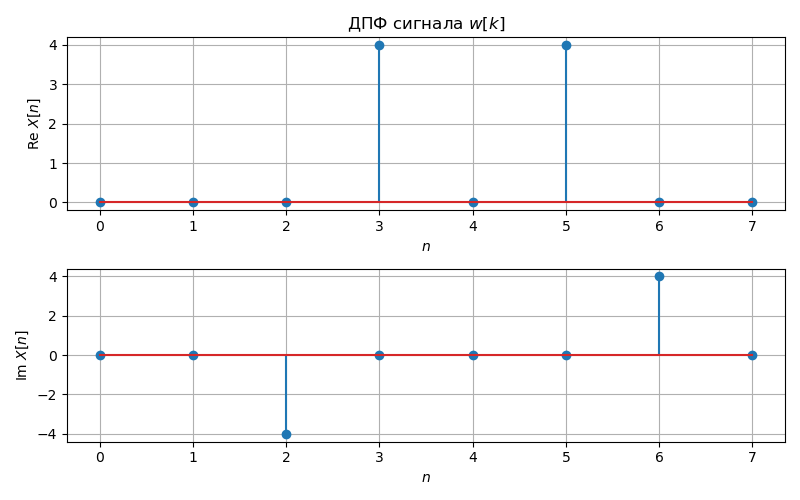

In [17]:
plt.figure(figsize=[8, 5])

n=np.arange(N)
plt.subplot(2, 1, 1)
plt.stem(n, Xn.real)
plt.xticks(n)
plt.title('ДПФ сигнала $w[k]$')
plt.xlabel('$n$')
plt.ylabel('Re $X[n]$')
plt.grid()

plt.subplot(2, 1, 2)
plt.stem(n, Xn.imag)
plt.xticks(n)
plt.xlabel('$n$')
plt.ylabel('Im $X[n]$')

plt.grid()
plt.tight_layout()
plt.show()

Теперь проведем вычисление ДПФ по алгоритму быстрого преобразования Фурье (БПФ). Для этого воспользуемся функцией `np.fft.fft()`.


In [18]:
Xn1=np.fft.fft(x)
Xn1

array([-3.09256603e-17+0.00000000e+00j,  6.66133815e-16+1.94671210e-16j,
       -1.07929736e-15-4.00000000e+00j,  4.00000000e+00-1.76476367e-15j,
        1.30134197e-15+0.00000000e+00j,  4.00000000e+00+1.76476367e-15j,
       -1.07929736e-15+4.00000000e+00j,  6.66133815e-16-1.94671210e-16j])

Сравним результаты.

In [19]:
max(abs(Xn1-Xn))

np.float64(4.2535579475330355e-15)

## Вычисление обратного ДПФ


Матрица обратного ДПФ может быть найдена как обратная матрица для $[W]_N$.

In [20]:
W8_inv1 = np.linalg.inv(W8)

Также ее можно получить с помощью транспонирования и комплексного сопряжения (эрмитова сопряжения) c дополнительной нормировкой на $N$, в силу того, что $[W]_N^{-1} =\frac{1}{N}{\left([W]_N^T \right)}^* =\frac{1}{N}[W]_N^*$. 


In [21]:
W8_inv2 = np.conjugate(W8) / N

Вычислим обратное ДПФ, используя матричную форму. Сравним результат с исходной последовательностью. 


In [22]:
x1 = W8_inv1 @ Xn
max(abs(x1-x))

np.float64(3.7840615182787717e-16)

Выполним те же вычисления с использованием алгоритма БПФ. Для этого нам понадобится функция `np.fft.ifft()`

In [23]:
x2=np.fft.ifft(Xn)
max(abs(x2-x))

np.float64(1.526600783182116e-15)

## Интерполяция ДВПФ добавлением нулевых отсчетов

Построим на одном графике модули ДПФ и ДВПФ $N$-точечной последовательности ($N=16$)

$$x[k]=\sin \left(2\pi \frac{5.5}{16} k \right),\;\;k=0,1,\dots ,N-1.$$

In [24]:
N=16
k=np.arange(N)
n=np.arange(N)
x=np.sin(2*np.pi*5.5*k/N)

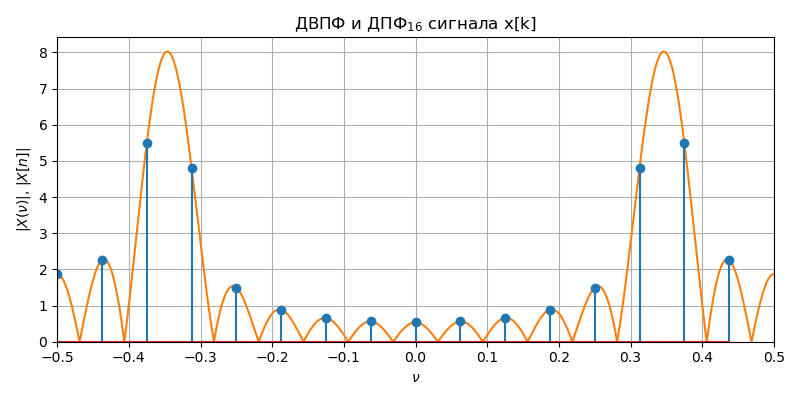

In [25]:
plt.figure(figsize=[8, 4])


nu, X = dtft(x, M=2048)
plt.plot(nu, abs(X), 'C1')

M=N
plt.stem(np.arange(M)/M-0.5, abs(np.fft.fftshift(np.fft.fft(x, M))), linefmt='C0', markerfmt='C0o')

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ и ДПФ$_{%i}$ сигнала x[k]' %M)
plt.xlabel('$\\nu$')
plt.ylabel('$|X(\\nu)|$, $|X[n]|$')
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()

Здесь функция `np.fft.fftshift` позволяет циклически сдвинуть вычисленные отсчеты ДПФ так, чтобы они соответствовали частотам$\nu_n \in [-0.5;0.5)$, $\nu_n =-0.5+\frac{n}{N}.$

Относительная частота синусойды $\nu_0 =\frac{6.5}{16}$ не попадет на сетку частот ДПФ. В результате спектральные максимумы недостаточно хорошо визуализируются отсчетами ДПФ. Чтобы это улучшить, добавим к последовательности, используемой при вычислении ДПФ, нулевые отсчеты в конец сигнала. Для этого досточно указать второй параметр функции `np.fft.fft(x, M)` равный новому числу отсчетов. 


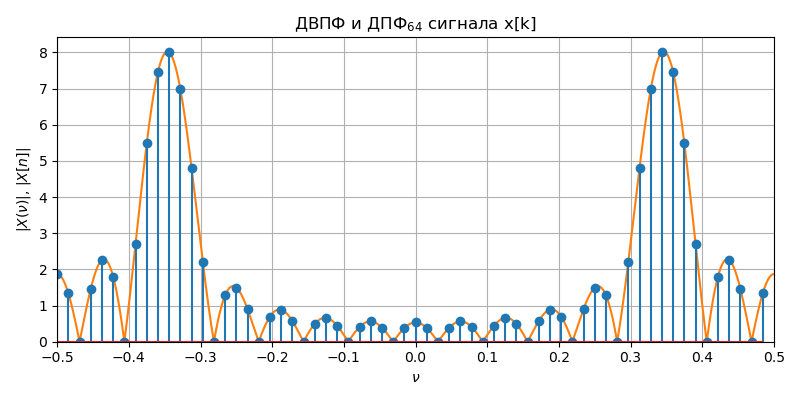

In [26]:
plt.figure(figsize=[8, 4])


nu, X = dtft(x, M=2048)
plt.plot(nu, abs(X), 'C1')

Nz=48
M=N+Nz
plt.stem(np.arange(M)/M-0.5, abs(np.fft.fftshift(np.fft.fft(x, M))), linefmt='C0', markerfmt='C0o')

plt.xlim([-0.5, 0.5])
plt.ylim(bottom=0)
plt.title('ДВПФ и ДПФ$_{%i}$ сигнала x[k]' %M)
plt.xlabel('$\\nu$')
plt.ylabel('$|X(\\nu)|$, $|X[n]|$')
plt.xticks(np.linspace(-0.5, 0.5, 11))
plt.grid()
plt.tight_layout()
plt.show()